# TalentMiner - Phase 2 Submission

**Group:** BSE-B-8

This notebook contains the complete model implementation and performance evaluation on the test dataset using Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.

In [2]:
# Core libraries
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='whitegrid')

In [3]:
# Load and prepare dataset
df = pd.read_csv('/content/drive/MyDrive/TalenMiner/Resume.csv')
df = df[['Resume_str', 'Category']].dropna().copy()

print(f'Dataset shape: {df.shape}')
print(f'Number of classes: {df["Category"].nunique()}')
df.head()

Dataset shape: (2484, 2)
Number of classes: 24


,Resume_str,Category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\n\nHR ADMINISTRATOR Summary Dedicated Customer Service Manag...,HR
1,"HR SPECIALIST, US HR OPERATIONS Summary Versatile media professional with background in Communic...",HR
2,"HR DIRECTOR Summary Over 20 years experience in recruiting, 15 plus years in Human Resources E...",HR
3,"HR SPECIALIST Summary Dedicated, Driven, and Dynamic with over 20 years of customer service expert...",HR
4,HR MANAGER Skill Highlights HR SKILLS HR Department Startup Three New Organization Star...,HR


In [4]:
# Train-test split (test data used for final evaluation)
X = df['Resume_str']
y = df['Category']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('Train size:', len(X_train))
print('Test size :', len(X_test))

Train size: 1987
Test size : 497


In [5]:
# Define and evaluate multiple models
models = {
    'Linear SVM': LinearSVC(),
    'Multinomial NB': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=3000)
}

results = []
predictions = {}

for name, clf in models.items():
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(stop_words='english', max_features=12000, ngram_range=(1, 2))),
        ('clf', clf)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    predictions[name] = y_pred

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision (Weighted)': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall (Weighted)': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1-Score (Weighted)': f1_score(y_test, y_pred, average='weighted', zero_division=0)
    })

results_df = pd.DataFrame(results).sort_values(by='F1-Score (Weighted)', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision (Weighted),Recall (Weighted),F1-Score (Weighted)
0,Linear SVM,0.722334,0.726435,0.722334,0.712632
1,Logistic Regression,0.655936,0.668261,0.655936,0.639655
2,Multinomial NB,0.555332,0.612726,0.555332,0.515674


In [6]:
# Detailed report for the best model
best_model_name = results_df.loc[0, 'Model']
best_pred = predictions[best_model_name]

print('Best model based on weighted F1-score:', best_model_name)
print('\nClassification Report:\n')
print(classification_report(y_test, best_pred, zero_division=0))

Best model based on weighted F1-score: Linear SVM

Classification Report:

                        precision    recall  f1-score   support

            ACCOUNTANT       0.70      0.88      0.78        24
              ADVOCATE       0.57      0.71      0.63        24
           AGRICULTURE       0.89      0.62      0.73        13
               APPAREL       0.55      0.32      0.40        19
                  ARTS       0.60      0.43      0.50        21
            AUTOMOBILE       1.00      0.29      0.44         7
              AVIATION       0.82      0.75      0.78        24
               BANKING       0.78      0.78      0.78        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.70      0.88      0.78        24
                  CHEF       0.83      0.79      0.81        24
          CONSTRUCTION       0.79      0.86      0.83        22
            CONSULTANT       0.77      0.43      0.56        23
              DESIGNER      

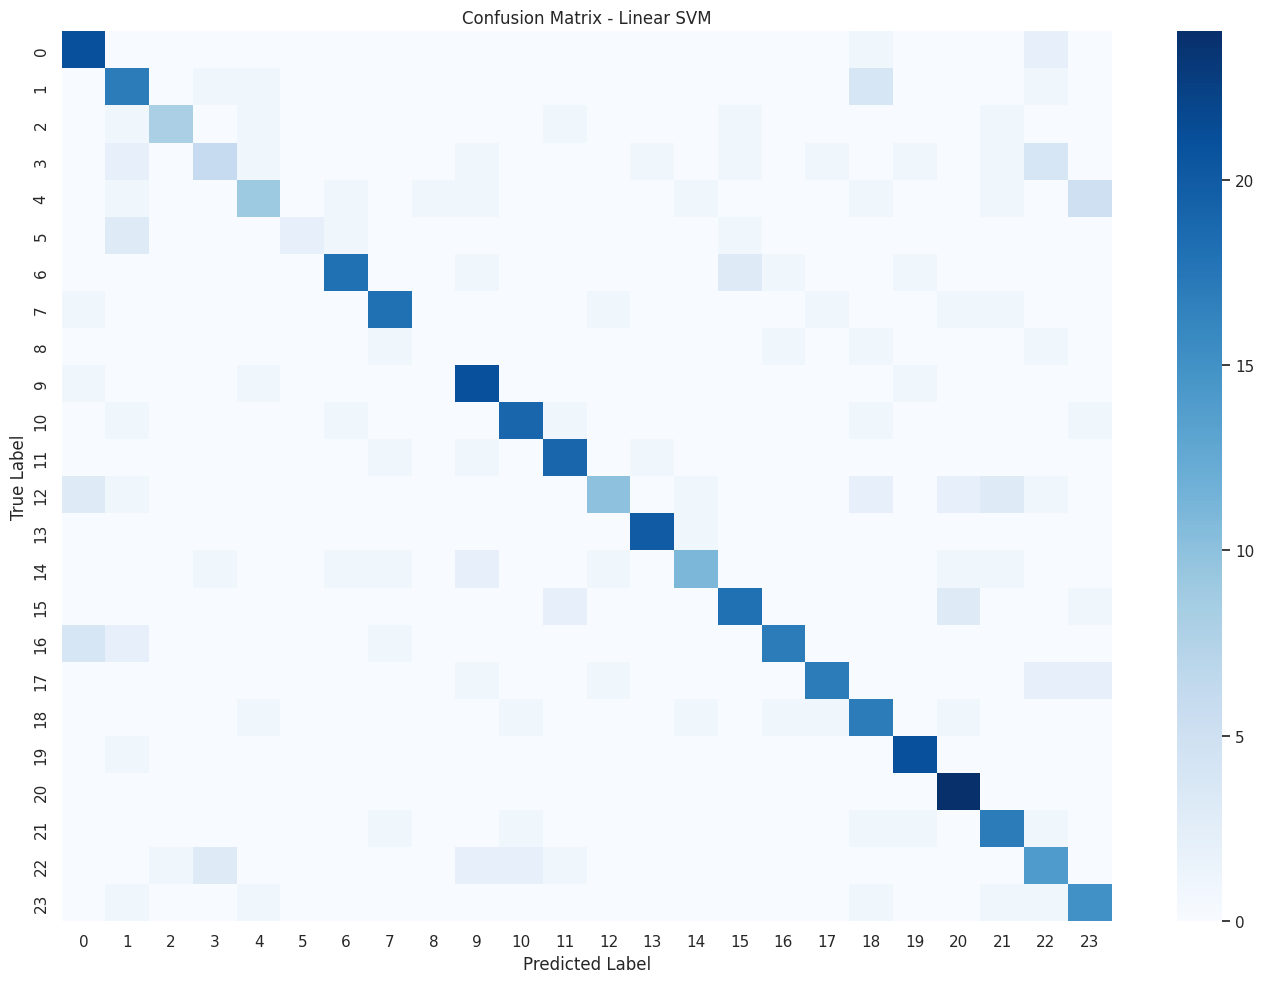

In [7]:
# Confusion Matrix for the best model
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, best_pred, labels=labels)

plt.figure(figsize=(14, 10))
sns.heatmap(cm, cmap='Blues', cbar=True)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## Final Notes
- All metrics are computed strictly on the test split.
- The confusion matrix visualizes final test-set predictions for the best-performing model.
- Notebook filename follows the required group naming format.